# 02 — FOV46 QC (interactive)
Start from raw FOV46. Inspect the recommended MAD thresholds, override any threshold, visualize what is removed, and save only when satisfied.

In [13]:
# ============================================================
# Dataset_02 CosMx — shared Jupyter initialization
# ============================================================
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

CURRENT_DIR = Path.cwd().resolve()

def find_project_root(start: Path) -> Path:
    """Find the nearest parent containing both src/ and data/."""
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not locate project root from {start}. "
        "Expected a parent containing src/ and data/."
    )

PROJECT_ROOT = find_project_root(CURRENT_DIR)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SPATIAL_DIR = PROJECT_ROOT / "data" / "spatial"
RESULTS_DIR = PROJECT_ROOT / "results"
CONFIG_DIR = PROJECT_ROOT / "config"

sc.settings.verbosity = 2

print("=" * 70)
print("Dataset_02 CosMx Jupyter environment")
print("=" * 70)
print("Notebook directory :", CURRENT_DIR)
print("Project root       :", PROJECT_ROOT)
print("Python             :", sys.executable)
print("src exists         :", (PROJECT_ROOT / "src").exists())
print("raw data exists    :", RAW_DIR.exists())
print("processed exists   :", PROCESSED_DIR.exists())
print("spatial exists     :", SPATIAL_DIR.exists())


Dataset_02 CosMx Jupyter environment
Notebook directory : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/jupyter-2
Project root       : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised
Python             : /home/jqu/.conda/envs/spatialdata/bin/python
src exists         : True
raw data exists    : True
processed exists   : True
spatial exists     : True


In [ ]:
from src.qc import add_qc_metrics, recommend_thresholds
from src.cosmx_io import control_mask

RAW_WHOLE = PROJECT_ROOT / "data/processed/GSM9046088_CosMx_raw.h5ad"
raw = sc.read_h5ad(RAW_WHOLE)
FOV = 46
f46 = raw[raw.obs["fov"].astype(str).eq(str(FOV))].copy()
add_qc_metrics(f46)
print(f46)

In [14]:
# Data-driven starting point.
NMADS = 3.0
recommended = recommend_thresholds(f46, nmads=NMADS)
recommended

{'min_counts': 75,
 'min_genes': 32,
 'max_counts': 2400,
 'max_control_fraction': 0.007182337045669567,
 'min_cell_area': 3337.0824715846375,
 'max_cell_area': 14913.890936282127}

## Editable QC parameters
Change any value below, then rerun the diagnostic cells. This does **not** overwrite production output until `SAVE_QC=True`.

In [15]:
QC = dict(recommended)
# Examples for manual testing:
# QC["min_counts"] = 75
# QC["min_genes"] = 32
# QC["max_counts"] = 2400
# QC["max_control_fraction"] = 0.0072
# QC["min_cell_area"] = 3300
# QC["max_cell_area"] = 15000
QC

{'min_counts': 75,
 'min_genes': 32,
 'max_counts': 2400,
 'max_control_fraction': 0.007182337045669567,
 'min_cell_area': 3337.0824715846375,
 'max_cell_area': 14913.890936282127}

In [16]:
def qc_mask_from_thresholds(a, q):
    o=a.obs
    keep=(o.total_counts>=q["min_counts"]) & (o.n_genes_by_counts>=q["min_genes"])
    if q.get("max_counts") is not None: keep &= o.total_counts<=q["max_counts"]
    if q.get("max_control_fraction") is not None: keep &= o.control_fraction<=q["max_control_fraction"]
    if "qc_cell_area" in o:
        if q.get("min_cell_area") is not None: keep &= o.qc_cell_area>=q["min_cell_area"]
        if q.get("max_cell_area") is not None: keep &= o.qc_cell_area<=q["max_cell_area"]
    return keep

keep = qc_mask_from_thresholds(f46, QC)
print(f"Retained: {keep.sum():,}/{len(keep):,} ({keep.mean():.1%})")

Retained: 938/1,105 (84.9%)


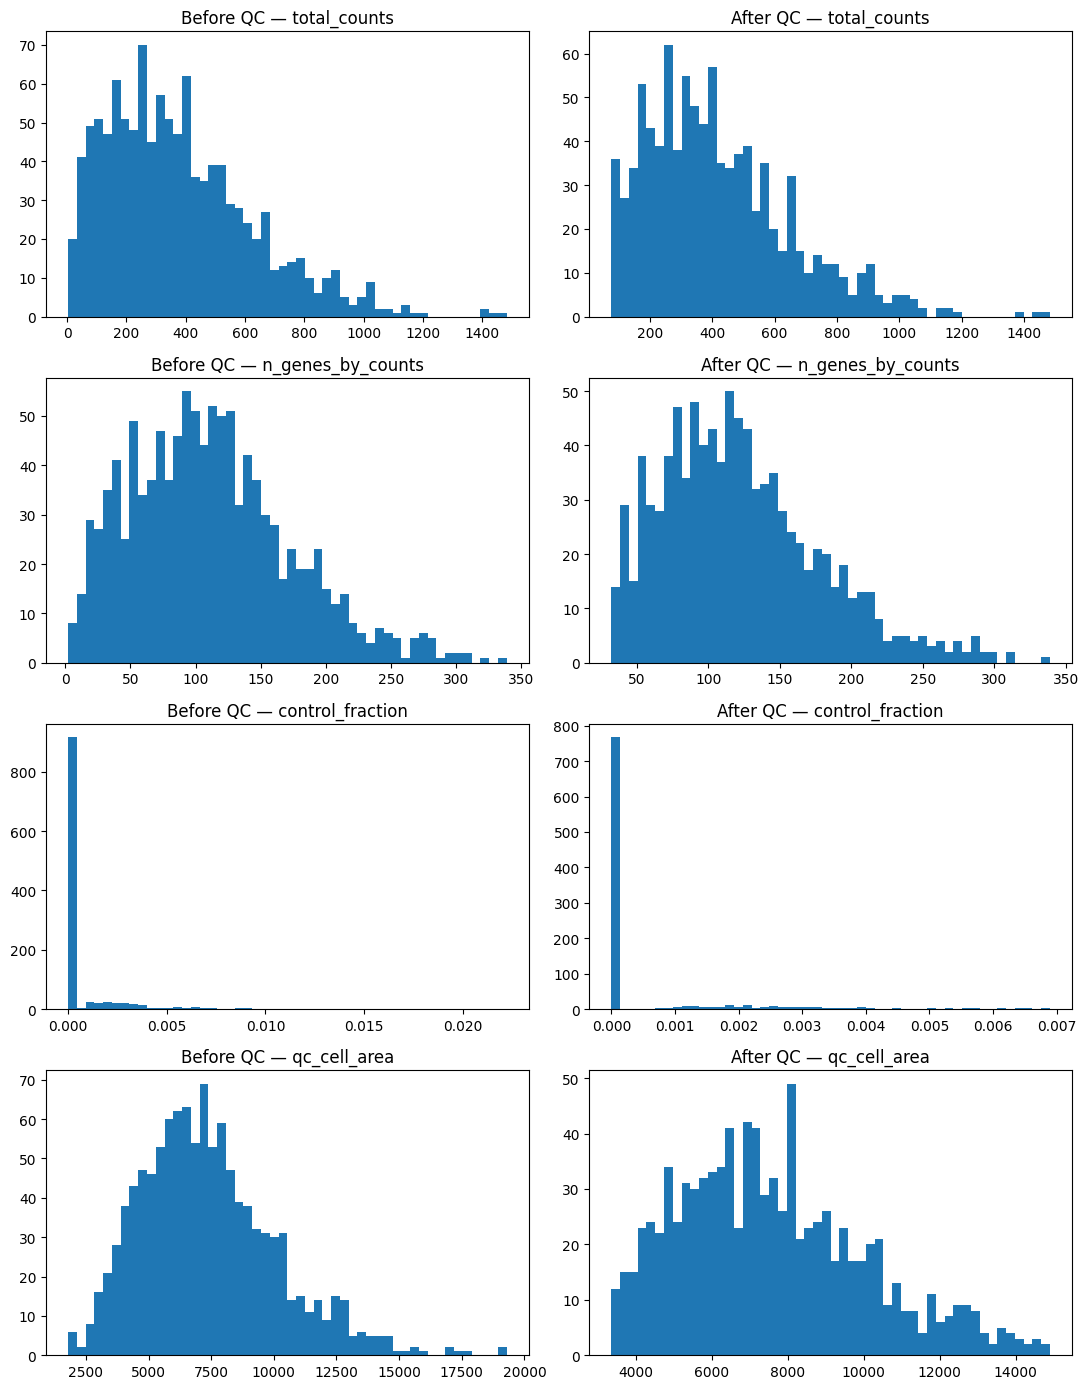

In [17]:
# Before/after distributions with thresholds.
metrics = [c for c in ["total_counts","n_genes_by_counts","control_fraction","qc_cell_area"] if c in f46.obs]
fig, axes = plt.subplots(len(metrics), 2, figsize=(11, 3.5*len(metrics)))
axes=np.atleast_2d(axes)
for i,col in enumerate(metrics):
    before=pd.to_numeric(f46.obs[col],errors="coerce").dropna(); after=pd.to_numeric(f46.obs.loc[keep,col],errors="coerce").dropna()
    axes[i,0].hist(before,bins=50); axes[i,0].set_title(f"Before QC — {col}")
    axes[i,1].hist(after,bins=50); axes[i,1].set_title(f"After QC — {col}")
plt.tight_layout(); plt.show()

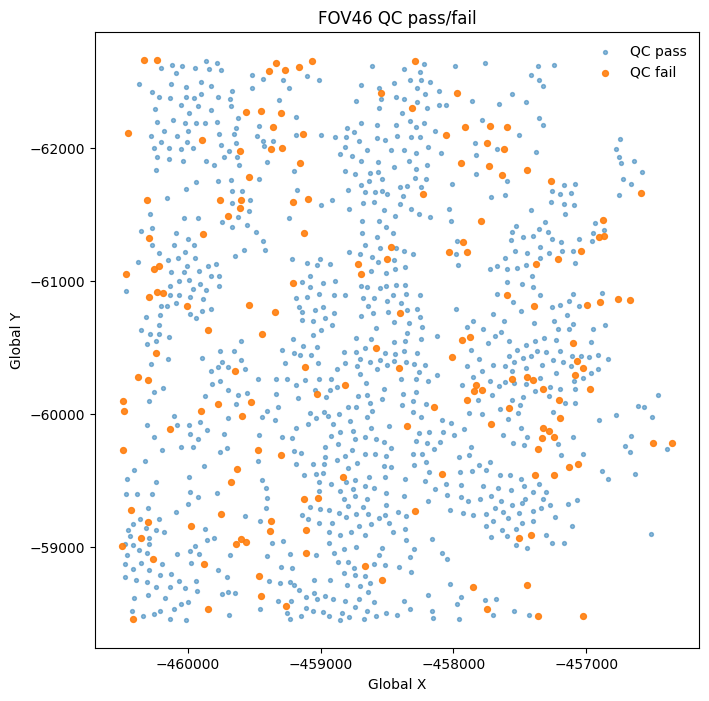

In [18]:
# Spatial QC pass/fail — essential for spatial data.
xy=np.asarray(f46.obsm["spatial"])
fig,ax=plt.subplots(figsize=(8,8))
ax.scatter(xy[keep,0],xy[keep,1],s=8,alpha=.5,label="QC pass")
ax.scatter(xy[~keep,0],xy[~keep,1],s=18,alpha=.9,label="QC fail")
ax.set_aspect("equal"); ax.invert_yaxis(); ax.set_xlabel("Global X"); ax.set_ylabel("Global Y")
ax.legend(frameon=False); ax.set_title("FOV46 QC pass/fail"); plt.show()

In [19]:
# ============================================================
# Build filtered biological object in memory
# ============================================================

biological = ~control_mask(f46.var_names)

q = f46[
    keep.to_numpy(),
    biological,
].copy()

sc.pp.filter_genes(
    q,
    min_cells=1,
)

# Preserve raw biological counts
q.layers["counts"] = q.X.copy()

print(q)

AnnData object with n_obs × n_vars = 938 × 1000
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.B2M.MembraneStain', 'Max.B2M.MembraneStain', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'n_genes_by_counts', 'total_counts', 'control_counts', 'control_fraction', 'qc_cell_area', 'qc_low_count_within_fov', 'qc_low_gene_within_fov'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'is_control', 'n_cells'
    uns: 'GEO_accession', 'fov_positions', 'platform', 'sample', 'spatial_coordinate_columns'
    obsm: 'spatial'
    layers: 'counts'


In [20]:
# ============================================================
# Versioned QC output configuration — EDIT HERE
# ============================================================
SAVE_QC = False
QC_TAG = "mad3_interactive"   # e.g. mad3, lenient, counts75_genes32

QC_OUTPUT_DIR = RESULTS_DIR / "FOV46" / "qc_variants" / QC_TAG
QC_OUTPUT_FILE = QC_OUTPUT_DIR / f"GSM9046088_FOV46_qc_filtered_{QC_TAG}.h5ad"
QC_THRESHOLDS_FILE = QC_OUTPUT_DIR / f"qc_thresholds_{QC_TAG}.json"

print("=" * 70)
print("QC output plan")
print("=" * 70)
print("SAVE_QC          :", SAVE_QC)
print("QC_TAG           :", QC_TAG)
print("Output directory :", QC_OUTPUT_DIR)
print("Output filename  :", QC_OUTPUT_FILE.name)
print("Full output path :", QC_OUTPUT_FILE)
print("Currently exists :", QC_OUTPUT_FILE.exists())


QC output plan
SAVE_QC          : False
QC_TAG           : mad3_interactive
Output directory : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/qc_variants/mad3_interactive
Output filename  : GSM9046088_FOV46_qc_filtered_mad3_interactive.h5ad
Full output path : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/qc_variants/mad3_interactive/GSM9046088_FOV46_qc_filtered_mad3_interactive.h5ad
Currently exists : False


In [21]:
# Save only after you are satisfied with the interactive QC result.
if SAVE_QC:
    QC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    q.write_h5ad(QC_OUTPUT_FILE, compression="gzip")
    QC_THRESHOLDS_FILE.write_text(json.dumps(QC, indent=2))
    print("Saved AnnData   :", QC_OUTPUT_FILE)
    print("Saved thresholds:", QC_THRESHOLDS_FILE)
else:
    print("SAVE_QC=False — q remains in memory only.")


SAVE_QC=False — q remains in memory only.


In [22]:
# Inspect the planned/saved location at any time.
print("Planned file:", QC_OUTPUT_FILE)
print("Exists      :", QC_OUTPUT_FILE.exists())
if QC_OUTPUT_FILE.exists():
    print(f"Size        : {QC_OUTPUT_FILE.stat().st_size / 1024**2:.2f} MB")
    print("Directory contents:")
    for path in sorted(QC_OUTPUT_DIR.glob("*")):
        print("  ", path.name)


Planned file: /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/qc_variants/mad3_interactive/GSM9046088_FOV46_qc_filtered_mad3_interactive.h5ad
Exists      : False


In [24]:
# ============================================================
# Save QC result
# ============================================================

SAVE_QC = True

if SAVE_QC:

    # Create output directory if needed
    QC_OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    # Save QC-filtered AnnData
    q.write_h5ad(
        QC_OUTPUT_FILE,
        compression="gzip",
    )

    # Save the exact QC thresholds used
    QC_THRESHOLDS_FILE.write_text(
        json.dumps(
            QC,
            indent=2,
        )
    )

    print("Saved successfully.")
    print()
    print("AnnData:")
    print(QC_OUTPUT_FILE)
    print()
    print("QC thresholds:")
    print(QC_THRESHOLDS_FILE)

else:

    print(
        "SAVE_QC=False — "
        "q remains in memory only."
    )

Saved successfully.

AnnData:
/research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/qc_variants/mad3_interactive/GSM9046088_FOV46_qc_filtered_mad3_interactive.h5ad

QC thresholds:
/research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/qc_variants/mad3_interactive/qc_thresholds_mad3_interactive.json


In [25]:
# ============================================================
# Verify saved outputs
# ============================================================

print("AnnData exists:")
print(QC_OUTPUT_FILE.exists())

print("\nThreshold file exists:")
print(QC_THRESHOLDS_FILE.exists())


if QC_OUTPUT_FILE.exists():

    size_mb = (
        QC_OUTPUT_FILE.stat().st_size
        / 1024**2
    )

    print(
        f"\nAnnData size: {size_mb:.2f} MB"
    )

    print("\nFull AnnData path:")
    print(QC_OUTPUT_FILE)


if QC_THRESHOLDS_FILE.exists():

    print("\nSaved QC thresholds:")

    with open(QC_THRESHOLDS_FILE) as f:
        saved_qc = json.load(f)

    display(saved_qc)

AnnData exists:
True

Threshold file exists:
True

AnnData size: 0.73 MB

Full AnnData path:
/research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/qc_variants/mad3_interactive/GSM9046088_FOV46_qc_filtered_mad3_interactive.h5ad

Saved QC thresholds:


{'min_counts': 75,
 'min_genes': 32,
 'max_counts': 2400,
 'max_control_fraction': 0.007182337045669567,
 'min_cell_area': 3337.0824715846375,
 'max_cell_area': 14913.890936282127}

In [26]:
# Reload test

q_test = sc.read_h5ad(
    QC_OUTPUT_FILE
)

print("Reload successful:")
print(q_test)

print(
    "\ncounts layer:",
    "counts" in q_test.layers,
)

print(
    "spatial coordinates:",
    "spatial" in q_test.obsm,
)

Reload successful:
AnnData object with n_obs × n_vars = 938 × 1000
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.B2M.MembraneStain', 'Max.B2M.MembraneStain', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'n_genes_by_counts', 'total_counts', 'control_counts', 'control_fraction', 'qc_cell_area', 'qc_low_count_within_fov', 'qc_low_gene_within_fov'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'is_control', 'n_cells'
    uns: 'GEO_accession', 'fov_positions', 'platform', 'sample', 'spatial_coordinate_columns'
    obsm: 'spatial'
    layers: 'counts'

counts layer: True
spatial coordinates: True
